In [1]:
# ============================================================
# SECTION 0 — Setup
# ============================================================

%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

YEAR = "2010"

OUTPUT_DIR = PROJECT_ROOT / "outputs" / YEAR
save_files = False
debug= True
if debug:
    print("PROJECT_ROOT:", PROJECT_ROOT)
    print("OUTPUT_DIR:", OUTPUT_DIR)

PROJECT_ROOT: /mnt/data/jhub/16-VenusExpres/dsn_multi_year
OUTPUT_DIR: /mnt/data/jhub/16-VenusExpres/dsn_multi_year/outputs/2010


In [2]:
# ============================================================
# SECTION 1 — Final detection settings
# ============================================================

TRANSIENT_THRESHOLD = 3.0

MIN_CONSEC_WINDOWS = 2
MIN_DURATION_HR = 0.33
MAX_DURATION_HR = 12.0

MERGE_GAP_HR = 0.67

INPUT_FILE = OUTPUT_DIR / f"phase_windows_detected_{YEAR}.csv"
OUTPUT_FILE = OUTPUT_DIR / f"final_cme_candidates_{YEAR}.csv"
if debug:
    print("INPUT_FILE:", INPUT_FILE)
    print("OUTPUT_FILE:", OUTPUT_FILE)

INPUT_FILE: /mnt/data/jhub/16-VenusExpres/dsn_multi_year/outputs/2010/phase_windows_detected_2010.csv
OUTPUT_FILE: /mnt/data/jhub/16-VenusExpres/dsn_multi_year/outputs/2010/final_cme_candidates_2010.csv


In [3]:
# ============================================================
# SECTION 2 — Load CIR-removed DSN window table
# ============================================================

windows_df = pd.read_csv(INPUT_FILE)

for col in ["start", "end", "mid"]:
    windows_df[col] = pd.to_datetime(windows_df[col], errors="coerce")

windows_df = windows_df.sort_values("mid").reset_index(drop=True)

required_cols = [
    "start",
    "end",
    "mid",
    "phase_rms_rad",
    "clean_signal",
]

missing = [c for c in required_cols if c not in windows_df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")
if debug:
    print("Rows:", len(windows_df))
    print("Time range:", windows_df["mid"].min(), "→", windows_df["mid"].max())
    print("Clean signal range:", windows_df["clean_signal"].min(), "→", windows_df["clean_signal"].max())
    
    display(windows_df.head())

Rows: 14590
Time range: 2010-01-01 09:47:20 → 2010-12-30 12:27:20
Clean signal range: 0.1512860628293095 → 129.27815654819366


,start,end,mid,phase_rms_rad,n_samples,day,elongation_deg,phase_expected,phase_ratio,phase_smooth,clean_signal,event_flag
0,2010-01-01 09:37:20,2010-01-01 09:57:20,2010-01-01 09:47:20,14.885682,120,2010-01-01,2.6407,12.796661,1.163247,1.191859,0.975994,False
1,2010-01-01 09:47:20,2010-01-01 10:07:20,2010-01-01 09:57:20,15.971841,120,2010-01-01,2.6407,12.796661,1.248126,1.163247,1.072967,False
2,2010-01-01 09:57:20,2010-01-01 10:17:20,2010-01-01 10:07:20,8.508995,120,2010-01-01,2.6407,12.796661,0.664939,1.191859,0.557900,False
3,2010-01-01 10:07:20,2010-01-01 10:27:20,2010-01-01 10:17:20,6.813039,120,2010-01-01,2.6407,12.796661,0.532408,1.220471,0.436231,False
4,2010-01-01 10:17:20,2010-01-01 10:37:20,2010-01-01 10:27:20,9.688446,120,2010-01-01,2.6407,12.796661,0.757107,1.191859,0.635232,False


Candidates are defined as intervals where the CIR-removed clean signal exceeds
a threshold of 3.0 for at least two consecutive 20-minute windows.

Nearby candidates separated by less than 0.67 hr are merged into single events.

In [4]:
# ============================================================
# SECTION 3 — Detect short transient excesses
# ============================================================

w = windows_df.copy().sort_values("mid").reset_index(drop=True)

w["candidate"] = w["clean_signal"] > TRANSIENT_THRESHOLD

events = []
in_event = False

for i in range(len(w)):
    row = w.loc[i]

    if row["candidate"] and not in_event:
        start_idx = i
        in_event = True

    if in_event:
        is_last = i == len(w) - 1
        next_off = (not is_last) and (not w.loc[i + 1, "candidate"])

        if is_last or next_off:
            end_idx = i
            sub = w.loc[start_idx:end_idx].copy()

            duration_hr = (
                sub["end"].max() - sub["start"].min()
            ).total_seconds() / 3600.0

            if (
                len(sub) >= MIN_CONSEC_WINDOWS
                and duration_hr >= MIN_DURATION_HR
                and duration_hr <= MAX_DURATION_HR
            ):
                events.append({
                    "start": sub["start"].min(),
                    "end": sub["end"].max(),
                    "mid": sub["mid"].median(),
                    "duration_hr": duration_hr,
                    "n_windows": len(sub),
                    "peak_clean_signal": sub["clean_signal"].max(),
                    "median_clean_signal": sub["clean_signal"].median(),
                    "peak_phase_rms_rad": sub["phase_rms_rad"].max(),
                    "median_phase_rms_rad": sub["phase_rms_rad"].median(),
                })

            in_event = False

events_df = pd.DataFrame(events)
if debug:
    print("Initial events:", len(events_df))
    display(events_df.head())

Initial events: 34


,start,end,mid,duration_hr,n_windows,peak_clean_signal,median_clean_signal,peak_phase_rms_rad,median_phase_rms_rad
0,2010-02-23 05:57:20,2010-02-23 06:37:20,2010-02-23 06:17:20,0.666667,3,4.855846,3.175085,5.921438,3.865849
1,2010-02-25 13:07:20,2010-02-25 13:57:20,2010-02-25 13:32:20,0.833333,4,7.073263,5.782677,25.919475,21.190213
2,2010-02-27 05:57:20,2010-02-27 06:37:20,2010-02-27 06:17:20,0.666667,3,12.321122,9.799374,12.021557,8.905643
3,2010-03-02 12:27:20,2010-03-02 12:57:20,2010-03-02 12:42:20,0.500000,2,5.890991,5.079463,21.734104,18.665291
4,2010-03-02 13:37:20,2010-03-02 14:07:20,2010-03-02 13:52:20,0.500000,2,3.169574,3.137594,13.153632,13.020914


In [5]:
# ============================================================
# SECTION 4 — Merge nearby candidates
# ============================================================

if events_df.empty:
    final_events = events_df.copy()

else:
    events_df = events_df.sort_values("start").reset_index(drop=True)

    merged = []
    current = events_df.iloc[0].copy()

    for i in range(1, len(events_df)):
        nxt = events_df.iloc[i]

        gap_hr = (
            nxt["start"] - current["end"]
        ).total_seconds() / 3600.0

        if gap_hr <= MERGE_GAP_HR:
            current["end"] = nxt["end"]
            current["mid"] = current["start"] + (current["end"] - current["start"]) / 2
            current["duration_hr"] = (
                current["end"] - current["start"]
            ).total_seconds() / 3600.0

            current["n_windows"] += nxt["n_windows"]
            current["peak_clean_signal"] = max(current["peak_clean_signal"], nxt["peak_clean_signal"])
            current["median_clean_signal"] = np.nanmedian([
                current["median_clean_signal"],
                nxt["median_clean_signal"]
            ])
            current["peak_phase_rms_rad"] = max(current["peak_phase_rms_rad"], nxt["peak_phase_rms_rad"])
            current["median_phase_rms_rad"] = np.nanmedian([
                current["median_phase_rms_rad"],
                nxt["median_phase_rms_rad"]
            ])

        else:
            merged.append(current)
            current = nxt.copy()

    merged.append(current)

    final_events = pd.DataFrame(merged)

final_events = final_events.reset_index(drop=True)
final_events.insert(0, "event_id", np.arange(1, len(final_events) + 1))
final_events.insert(1, "year", YEAR)

if debug:
    print("Final CME-like candidates:", len(final_events))
    display(final_events)

Final CME-like candidates: 32


,event_id,year,start,end,mid,duration_hr,n_windows,peak_clean_signal,median_clean_signal,peak_phase_rms_rad,median_phase_rms_rad
0,1,2010,2010-02-23 05:57:20,2010-02-23 06:37:20,2010-02-23 06:17:20,0.666667,3,4.855846,3.175085,5.921438,3.865849
1,2,2010,2010-02-25 13:07:20,2010-02-25 13:57:20,2010-02-25 13:32:20,0.833333,4,7.073263,5.782677,25.919475,21.190213
2,3,2010,2010-02-27 05:57:20,2010-02-27 06:37:20,2010-02-27 06:17:20,0.666667,3,12.321122,9.799374,12.021557,8.905643
3,4,2010,2010-03-02 12:27:20,2010-03-02 14:07:20,2010-03-02 13:17:20,1.666667,4,5.890991,4.108528,21.734104,15.843103
4,5,2010,2010-03-07 08:57:20,2010-03-07 10:07:20,2010-03-07 09:32:20,1.166667,6,8.801972,6.547353,9.113606,6.779162
5,6,2010,2010-04-12 13:27:20,2010-04-12 13:57:20,2010-04-12 13:42:20,0.500000,2,4.401309,4.158418,3.705392,3.500906
6,7,2010,2010-04-13 04:57:20,2010-04-13 05:37:20,2010-04-13 05:17:20,0.666667,3,3.820378,3.154946,3.065988,2.531956
7,8,2010,2010-06-05 11:17:20,2010-06-05 11:47:20,2010-06-05 11:32:20,0.500000,2,4.052692,3.766941,4.957834,4.608263
8,9,2010,2010-06-15 12:57:20,2010-06-15 13:27:20,2010-06-15 13:12:20,0.500000,2,3.846101,3.811634,2.849122,2.823590
9,10,2010,2010-06-25 09:47:20,2010-06-25 10:27:20,2010-06-25 10:07:20,0.666667,3,4.128069,3.307911,1.868963,1.497641


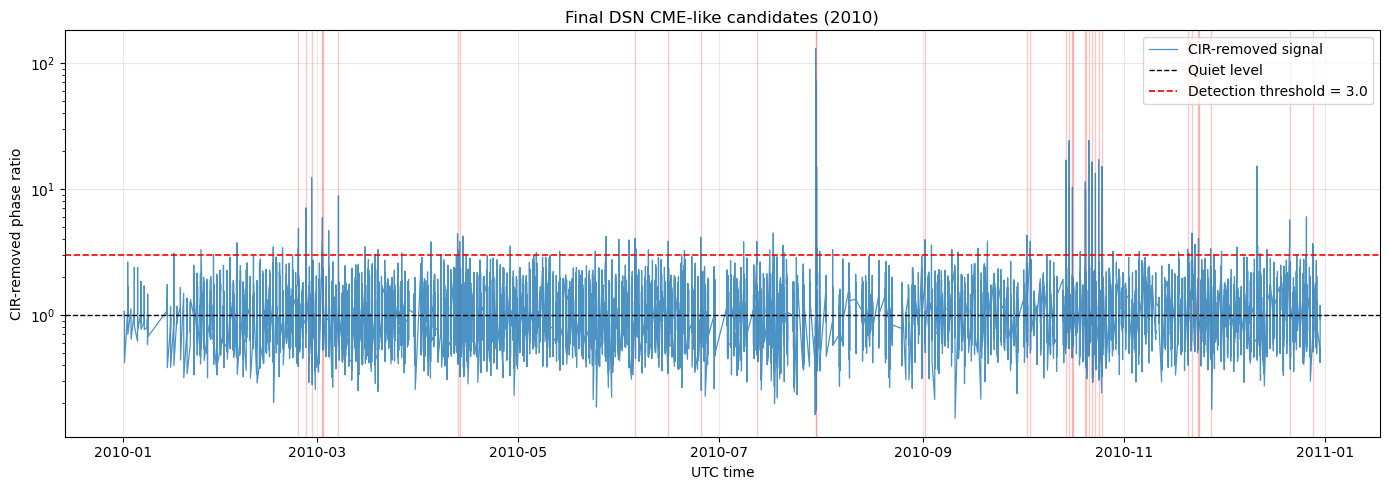

In [6]:
# ============================================================
# SECTION 5 — Plot final candidates
# ============================================================

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    w["mid"],
    w["clean_signal"],
    linewidth=0.9,
    alpha=0.8,
    label="CIR-removed signal"
)

ax.axhline(
    1.0,
    color="black",
    linestyle="--",
    linewidth=1,
    label="Quiet level"
)

ax.axhline(
    TRANSIENT_THRESHOLD,
    color="red",
    linestyle="--",
    linewidth=1.2,
    label=f"Detection threshold = {TRANSIENT_THRESHOLD}"
)

if not final_events.empty:
    for _, e in final_events.iterrows():
        ax.axvspan(e["start"], e["end"], color="red", alpha=0.22)

ax.set_yscale("log")
ax.set_xlabel("UTC time")
ax.set_ylabel("CIR-removed phase ratio")
ax.set_title(f"Final DSN CME-like candidates ({YEAR})")
ax.grid(True, alpha=0.3)
ax.legend(loc="upper right")

plt.tight_layout()
plt.show()

In [7]:
# ============================================================
# SECTION 6 — Candidate/background consistency diagnostics
# ============================================================

diagnostic_rows = []

for _, e in final_events.iterrows():

    event_mask = (
        (w["mid"] >= e["start"]) &
        (w["mid"] <= e["end"])
    )

    local_mask = (
        (w["mid"] >= e["start"] - pd.Timedelta(hours=12)) &
        (w["mid"] <= e["end"] + pd.Timedelta(hours=12))
    )

    background_mask = local_mask & ~event_mask

    evt = w.loc[event_mask]
    bg = w.loc[background_mask]

    if len(bg) == 0:
        bg_median = np.nan
        contrast = np.nan
    else:
        bg_median = bg["clean_signal"].median()
        contrast = evt["clean_signal"].median() / bg_median

    diagnostic_rows.append({
        "event_id": e["event_id"],
        "start": e["start"],
        "end": e["end"],
        "duration_hr": e["duration_hr"],
        "peak_clean_signal": e["peak_clean_signal"],
        "event_median_clean": evt["clean_signal"].median(),
        "local_background_median": bg_median,
        "contrast_ratio": contrast,
    })

diagnostics_df = pd.DataFrame(diagnostic_rows)

if debug:
    display(diagnostics_df.head(10))
    
    print("Median contrast ratio:", diagnostics_df["contrast_ratio"].median())
    print("Minimum contrast ratio:", diagnostics_df["contrast_ratio"].min())
    print("Maximum contrast ratio:", diagnostics_df["contrast_ratio"].max())

,event_id,start,end,duration_hr,peak_clean_signal,event_median_clean,local_background_median,contrast_ratio
0,1,2010-02-23 05:57:20,2010-02-23 06:37:20,0.666667,4.855846,3.020749,0.932602,3.239055
1,2,2010-02-25 13:07:20,2010-02-25 13:57:20,0.833333,7.073263,4.577710,1.068764,4.283181
2,3,2010-02-27 05:57:20,2010-02-27 06:37:20,0.666667,12.321122,4.409979,0.995582,4.429549
3,4,2010-03-02 12:27:20,2010-03-02 14:07:20,1.666667,5.890991,2.801266,1.050198,2.667370
4,5,2010-03-07 08:57:20,2010-03-07 10:07:20,1.166667,8.801972,5.781130,0.999551,5.783728
5,6,2010-04-12 13:27:20,2010-04-12 13:57:20,0.500000,4.401309,3.005749,0.972499,3.090749
6,7,2010-04-13 04:57:20,2010-04-13 05:37:20,0.666667,3.820378,3.004509,0.882507,3.404516
7,8,2010-06-05 11:17:20,2010-06-05 11:47:20,0.500000,4.052692,3.223935,1.004717,3.208800
8,9,2010-06-15 12:57:20,2010-06-15 13:27:20,0.500000,3.846101,2.715000,1.013787,2.678079
9,10,2010-06-25 09:47:20,2010-06-25 10:27:20,0.666667,4.128069,3.127143,1.056232,2.960658


Median contrast ratio: 3.4792710205734005
Minimum contrast ratio: 2.165893141744152
Maximum contrast ratio: 33.017980901891676


In [8]:
# ============================================================
# SECTION 7 — Save candidate and diagnostic tables
# ============================================================

if save_files:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

    final_events.to_csv(OUTPUT_FILE, index=False)

    diagnostics_file = OUTPUT_DIR / f"final_cme_candidate_diagnostics_{YEAR}.csv"
    diagnostics_df.to_csv(diagnostics_file, index=False)

    print("Saved candidate table:", OUTPUT_FILE)
    print("Saved diagnostics table:", diagnostics_file)

## CACTUS check


In [9]:
# ============================================================
# SECTION 0 — Setup
# ============================================================

%load_ext autoreload
%autoreload 2

import numpy as np
import sys
from pathlib import Path
import importlib

PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import matplotlib.pyplot as plt


# ----------------------------------------
# Load year-specific settings dynamically
# ----------------------------------------
settings = importlib.import_module(f"config.settings_{YEAR}")

for k in dir(settings):
    if not k.startswith("_"):
        globals()[k] = getattr(settings, k)

# ----------------------------------------
# Imports
# ----------------------------------------
from src.geometry_utils import (
    build_vex_earth_p_point_geometry_grid,
    add_projected_p_point_geometry,
)

from src.detection_utils import (
    FinalCMEConfig,
    load_final_cme_input,
    detect_final_cme_candidates,
    compute_final_cme_contrast,
    add_event_median_columns,
    match_cactus_to_dsn_candidates,
)

from src.plot_utils import plot_final_cme_candidates
from src.io_utils import load_horizons_daily_sep

# ----------------------------------------
debug = True
sav_file = False

OUTPUT_DIR = PROJECT_ROOT / "outputs" / YEAR

print("YEAR:", YEAR)
print("PROJECT_ROOT:", PROJECT_ROOT)
print("OUTPUT_DIR:", OUTPUT_DIR)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
YEAR: 2010
PROJECT_ROOT: /mnt/data/jhub/16-VenusExpres/dsn_multi_year
OUTPUT_DIR: /mnt/data/jhub/16-VenusExpres/dsn_multi_year/outputs/2010


In [10]:
# ============================================================
# SECTION 1 — Final CME-candidate settings
# ============================================================

final_cme_config = FinalCMEConfig(
    threshold=3.0,
    min_consec_windows=2,
    min_duration_hr=0.33,
    max_duration_hr=12.0,
    merge_gap_hr=0.67,
    local_background_hr=12.0,
)

INPUT_FILE = OUTPUT_DIR / f"phase_windows_detected_{YEAR}.csv"
OUTPUT_FILE = OUTPUT_DIR / f"final_cme_candidates_{YEAR}.csv"
CHECK_FILE = OUTPUT_DIR / f"final_cme_candidate_contrast_{YEAR}.csv"
FIG_FILE = OUTPUT_DIR / f"final_cme_candidates_{YEAR}.png"

if debug:
    print("INPUT_FILE:", INPUT_FILE)
    print("HORIZONS_FILE:", HORIZONS_FILE)
    print("OUTPUT_FILE:", OUTPUT_FILE)

INPUT_FILE: /mnt/data/jhub/16-VenusExpres/dsn_multi_year/outputs/2010/phase_windows_detected_2010.csv
HORIZONS_FILE: /mnt/data/jhub/16-VenusExpres/dsn_multi_year/inputs/2010_horizons.txt
OUTPUT_FILE: /mnt/data/jhub/16-VenusExpres/dsn_multi_year/outputs/2010/final_cme_candidates_2010.csv


In [11]:
# ============================================================
# SECTION 2 — Load CIR-removed DSN window table
# ============================================================

windows_df = load_final_cme_input(INPUT_FILE)

if debug:
    print("Rows:", len(windows_df))
    print("Time range:", windows_df["mid"].min(), "→", windows_df["mid"].max())
    print("Clean signal range:",
          windows_df["clean_signal"].min(),
          "→",
          windows_df["clean_signal"].max())
    display(windows_df.head())

Rows: 14590
Time range: 2010-01-01 09:47:20 → 2010-12-30 12:27:20
Clean signal range: 0.1512860628293095 → 129.27815654819366


,start,end,mid,phase_rms_rad,n_samples,day,elongation_deg,phase_expected,phase_ratio,phase_smooth,clean_signal,event_flag
0,2010-01-01 09:37:20,2010-01-01 09:57:20,2010-01-01 09:47:20,14.885682,120,2010-01-01,2.6407,12.796661,1.163247,1.191859,0.975994,False
1,2010-01-01 09:47:20,2010-01-01 10:07:20,2010-01-01 09:57:20,15.971841,120,2010-01-01,2.6407,12.796661,1.248126,1.163247,1.072967,False
2,2010-01-01 09:57:20,2010-01-01 10:17:20,2010-01-01 10:07:20,8.508995,120,2010-01-01,2.6407,12.796661,0.664939,1.191859,0.557900,False
3,2010-01-01 10:07:20,2010-01-01 10:27:20,2010-01-01 10:17:20,6.813039,120,2010-01-01,2.6407,12.796661,0.532408,1.220471,0.436231,False
4,2010-01-01 10:17:20,2010-01-01 10:37:20,2010-01-01 10:27:20,9.688446,120,2010-01-01,2.6407,12.796661,0.757107,1.191859,0.635232,False


In [12]:
# ============================================================
# SECTION 3 — Add true LOS closest-approach P-point geometry
# ============================================================

from src.geometry_utils import (
    build_vex_earth_p_point_geometry_grid,
    add_projected_p_point_geometry,
)

# Add small buffer so interpolation covers all windows
geom_start = windows_df["mid"].min() - pd.Timedelta(hours=1)
geom_stop  = windows_df["mid"].max() + pd.Timedelta(hours=1)

geom_grid = build_vex_earth_p_point_geometry_grid(
    start=geom_start,
    stop=geom_stop,
    step="10m",
)

windows_df = add_projected_p_point_geometry(
    windows_df,
    geom_grid,
    mid_col="mid",
)

if debug:
    print("Geometry rows:", len(geom_grid))
    print("Geometry time range:",
          geom_grid["time"].min(),
          "→",
          geom_grid["time"].max())

    print("P-point range AU:",
          windows_df["p_point_AU"].min(),
          "→",
          windows_df["p_point_AU"].max())

    print("P-point longitude range:",
          windows_df["p_lon_deg"].min(),
          "→",
          windows_df["p_lon_deg"].max())

    print("P-point latitude range:",
          windows_df["p_lat_deg"].min(),
          "→",
          windows_df["p_lat_deg"].max())

    display(
        windows_df[
            ["mid", "p_point_AU", "p_lon_deg", "p_lat_deg", "los_length_AU"]
        ].head()
    )

Geometry rows: 52301
Geometry time range: 2010-01-01 08:47:20+00:00 → 2010-12-30 13:27:20+00:00
P-point range AU: 0.018550575729632476 → 0.7284020012577529
P-point longitude range: 0.9085666234420842 → 359.6982940086496
P-point latitude range: -56.278714710279694 → 2.8895635728981253


,mid,p_point_AU,p_lon_deg,p_lat_deg,los_length_AU
0,2010-01-01 09:47:20+00:00,0.043554,188.146018,-10.464637,1.708452
1,2010-01-01 09:57:20+00:00,0.043528,188.154469,-10.484377,1.708454
2,2010-01-01 10:07:20+00:00,0.043502,188.162924,-10.503905,1.708457
3,2010-01-01 10:17:20+00:00,0.043476,188.171380,-10.523228,1.708459
4,2010-01-01 10:27:20+00:00,0.043450,188.179840,-10.542355,1.708461


In [13]:
# ============================================================
# SECTION 4 — Detect final CME-like candidates
# ============================================================

windows_flagged, final_events = detect_final_cme_candidates(
    windows_df,
    year=YEAR,
    config=final_cme_config,
)

# Make event/window times consistently UTC-aware
windows_flagged["mid"] = pd.to_datetime(windows_flagged["mid"], utc=True)
windows_df["mid"] = pd.to_datetime(windows_df["mid"], utc=True)

for c in ["start", "end", "mid"]:
    if c in final_events.columns:
        final_events[c] = pd.to_datetime(final_events[c], utc=True)

if debug:
    print("Final CME-like candidates:", len(final_events))
    display(final_events)

# ============================================================
# SECTION 4.5 — Add event-level geometry summaries
# ============================================================

final_events = add_event_median_columns(
    final_events,
    windows_df,
    columns=["p_point_AU", "p_lon_deg", "p_lat_deg"],
)

if debug:
    display(
        final_events[
            ["event_id", "p_point_AU_median", "p_lon_deg_median", "p_lat_deg_median"]
        ]
    )

Final CME-like candidates: 32


,event_id,year,start,end,mid,duration_hr,n_windows,peak_clean_signal,median_clean_signal,peak_phase_rms_rad,median_phase_rms_rad,elongation_deg_median,p_point_AU_median
0,1,2010,2010-02-23 05:57:20+00:00,2010-02-23 06:37:20+00:00,2010-02-23 06:17:20+00:00,0.666667,3,4.855846,3.175085,5.921438,3.865849,10.2293,0.176806
1,2,2010,2010-02-25 13:07:20+00:00,2010-02-25 13:57:20+00:00,2010-02-25 13:32:20+00:00,0.833333,4,7.073263,5.782677,25.919475,21.190213,10.7083,0.186236
2,3,2010,2010-02-27 05:57:20+00:00,2010-02-27 06:37:20+00:00,2010-02-27 06:17:20+00:00,0.666667,3,12.321122,9.799374,12.021557,8.905643,11.1880,0.193237
3,4,2010,2010-03-02 12:27:20+00:00,2010-03-02 14:07:20+00:00,2010-03-02 13:17:20+00:00,1.666667,4,5.890991,4.108528,21.734104,15.843103,11.9086,0.206656
4,5,2010,2010-03-07 08:57:20+00:00,2010-03-07 10:07:20+00:00,2010-03-07 09:32:20+00:00,1.166667,6,8.801972,6.547353,9.113606,6.779162,13.1120,0.226689
5,6,2010,2010-04-12 13:27:20+00:00,2010-04-12 13:57:20+00:00,2010-04-12 13:42:20+00:00,0.500000,2,4.401309,4.158418,3.705392,3.500906,21.8738,0.375734
6,7,2010,2010-04-13 04:57:20+00:00,2010-04-13 05:37:20+00:00,2010-04-13 05:17:20+00:00,0.666667,3,3.820378,3.154946,3.065988,2.531956,22.1187,0.378418
7,8,2010,2010-06-05 11:17:20+00:00,2010-06-05 11:47:20+00:00,2010-06-05 11:32:20+00:00,0.500000,2,4.052692,3.766941,4.957834,4.608263,34.7810,0.580390
8,9,2010,2010-06-15 12:57:20+00:00,2010-06-15 13:27:20+00:00,2010-06-15 13:12:20+00:00,0.500000,2,3.846101,3.811634,2.849122,2.823590,36.9698,0.612616
9,10,2010,2010-06-25 09:47:20+00:00,2010-06-25 10:27:20+00:00,2010-06-25 10:07:20+00:00,0.666667,3,4.128069,3.307911,1.868963,1.497641,39.0367,0.641418


,event_id,p_point_AU_median,p_lon_deg_median,p_lat_deg_median
0,1,0.176806,74.775347,-7.934604
1,2,0.186236,77.635137,-7.500221
2,3,0.193237,79.741837,-7.051307
3,4,0.206777,83.829778,-6.440415
4,5,0.226689,89.825310,-5.467872
5,6,0.375734,134.413607,-0.095398
6,7,0.378418,135.211701,0.019906
7,8,0.580390,199.502174,2.757588
8,9,0.612616,211.331652,2.625383
9,10,0.641418,222.781521,2.340834


In [14]:
# ============================================================
# SECTION 5 — CACTus catalogue consistency check
# ============================================================

CACTUS_FILE = PROJECT_ROOT / "inputs" / f"cactus_cmes_{YEAR}.csv"
cactus_df = pd.read_csv(CACTUS_FILE)

# ------------------------------------------------------------
# Fix time columns (CRITICAL)
# ------------------------------------------------------------

# Your CACTus launch column is 't0'
cactus_df["t0"] = pd.to_datetime(
    cactus_df["t0"],
    utc=True,
    errors="coerce"
)

# Ensure event times are also UTC-aware
for c in ["start", "end", "mid"]:
    if c in final_events.columns:
        final_events[c] = pd.to_datetime(
            final_events[c],
            utc=True,
            errors="coerce"
        )

# ------------------------------------------------------------
# Select angle column
# ------------------------------------------------------------

if "los_pa_deg_median" in final_events.columns:
    EVENT_ANGLE_COL = "los_pa_deg_median"
elif "p_lon_deg_median" in final_events.columns:
    EVENT_ANGLE_COL = "p_lon_deg_median"
else:
    EVENT_ANGLE_COL = None

# ------------------------------------------------------------
# Match CACTus to DSN candidates
# ------------------------------------------------------------

final_events = match_cactus_to_dsn_candidates(
    final_events,
    cactus_df,
    p_col="p_point_AU_median",
    event_angle_col=EVENT_ANGLE_COL,
    radial_tolerance_AU=0.20,
    angle_tolerance_deg=15.0,
)

# ------------------------------------------------------------
# Debug output
# ------------------------------------------------------------

if debug:
    print("Using event angle column:", EVENT_ANGLE_COL)

    print("\nCACTus crossing counts:")
    print(final_events["cactus_crosses_p_point"].value_counts(dropna=False))

    print("\nCACTus direction consistency counts:")
    print(final_events["cactus_direction_consistent"].value_counts(dropna=False))

    display(final_events)

Using event angle column: p_lon_deg_median

CACTus crossing counts:
cactus_crosses_p_point
False    17
True     15
Name: count, dtype: int64

CACTus direction consistency counts:
cactus_direction_consistent
False    17
True     15
Name: count, dtype: int64


,event_id,year,start,end,mid,duration_hr,n_windows,peak_clean_signal,median_clean_signal,peak_phase_rms_rad,...,matched_cactus_launch_utc,matched_cactus_speed_kms,matched_cactus_pa_deg,matched_cactus_width_deg,matched_cactus_half_width_deg,cactus_predicted_distance_AU,cactus_radial_error_AU,event_angle_deg,cactus_angle_error_deg,cactus_angle_allowed_deg
0,1,2010,2010-02-23 05:57:20+00:00,2010-02-23 06:37:20+00:00,2010-02-23 06:17:20+00:00,0.666667,3,4.855846,3.175085,5.921438,...,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,2010,2010-02-25 13:07:20+00:00,2010-02-25 13:57:20+00:00,2010-02-25 13:32:20+00:00,0.833333,4,7.073263,5.782677,25.919475,...,2010-02-24 17:06:00+00:00,215.0,116.0,50.0,25.0,0.105748,0.080488,77.635137,38.364863,40.0
2,3,2010,2010-02-27 05:57:20+00:00,2010-02-27 06:37:20+00:00,2010-02-27 06:17:20+00:00,0.666667,3,12.321122,9.799374,12.021557,...,2010-02-24 17:06:00+00:00,215.0,116.0,50.0,25.0,0.316583,0.123346,79.741837,36.258163,40.0
3,4,2010,2010-03-02 12:27:20+00:00,2010-03-02 14:07:20+00:00,2010-03-02 13:17:20+00:00,1.666667,4,5.890991,4.108528,21.734104,...,2010-03-01 22:06:00+00:00,868.0,60.0,34.0,17.0,0.317265,0.110489,83.829778,23.829778,32.0
4,5,2010,2010-03-07 08:57:20+00:00,2010-03-07 10:07:20+00:00,2010-03-07 09:32:20+00:00,1.166667,6,8.801972,6.547353,9.113606,...,2010-03-06 08:27:00+00:00,538.0,114.0,30.0,15.0,0.324819,0.098130,89.825310,24.174690,30.0
5,6,2010,2010-04-12 13:27:20+00:00,2010-04-12 13:57:20+00:00,2010-04-12 13:42:20+00:00,0.500000,2,4.401309,4.158418,3.705392,...,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,7,2010,2010-04-13 04:57:20+00:00,2010-04-13 05:37:20+00:00,2010-04-13 05:17:20+00:00,0.666667,3,3.820378,3.154946,3.065988,...,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,8,2010,2010-06-05 11:17:20+00:00,2010-06-05 11:47:20+00:00,2010-06-05 11:32:20+00:00,0.500000,2,4.052692,3.766941,4.957834,...,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,9,2010,2010-06-15 12:57:20+00:00,2010-06-15 13:27:20+00:00,2010-06-15 13:12:20+00:00,0.500000,2,3.846101,3.811634,2.849122,...,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,10,2010,2010-06-25 09:47:20+00:00,2010-06-25 10:27:20+00:00,2010-06-25 10:07:20+00:00,0.666667,3,4.128069,3.307911,1.868963,...,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [15]:
# ============================================================
# SECTION 6 — Save DSN/CACTus-matched events for PRIDE notebook
# ============================================================

EVENTS_FOR_PRIDE_FILE = OUTPUT_DIR / f"dsn_cactus_events_for_pride_{YEAR}.csv"

cols_for_pride = [
    "event_id", "year", "start", "end", "mid", "duration_hr", "n_windows",
    "peak_clean_signal", "median_clean_signal", "peak_phase_rms_rad",
    "p_point_AU_median", "event_angle_deg",
    "cactus_crosses_p_point", "cactus_direction_consistent",
    "matched_cactus_launch_utc", "matched_cactus_speed_kms",
    "matched_cactus_pa_deg", "matched_cactus_width_deg",
    "cactus_predicted_distance_AU", "cactus_radial_error_AU",
    "cactus_angle_error_deg", "cactus_angle_allowed_deg",
]

cols_for_pride = [c for c in cols_for_pride if c in final_events.columns]

events_for_pride = final_events[cols_for_pride].cowdpy()

events_for_pride.to_csv(EVENTS_FOR_PRIDE_FILE, index=False)

print("Saved:", EVENTS_FOR_PRIDE_FILE)
display(events_for_pride)

Saved: /mnt/data/jhub/16-VenusExpres/dsn_multi_year/outputs/2010/dsn_cactus_events_for_pride_2010.csv


,event_id,year,start,end,mid,duration_hr,n_windows,peak_clean_signal,median_clean_signal,peak_phase_rms_rad,...,cactus_crosses_p_point,cactus_direction_consistent,matched_cactus_launch_utc,matched_cactus_speed_kms,matched_cactus_pa_deg,matched_cactus_width_deg,cactus_predicted_distance_AU,cactus_radial_error_AU,cactus_angle_error_deg,cactus_angle_allowed_deg
0,1,2010,2010-02-23 05:57:20+00:00,2010-02-23 06:37:20+00:00,2010-02-23 06:17:20+00:00,0.666667,3,4.855846,3.175085,5.921438,...,False,False,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,2010,2010-02-25 13:07:20+00:00,2010-02-25 13:57:20+00:00,2010-02-25 13:32:20+00:00,0.833333,4,7.073263,5.782677,25.919475,...,True,True,2010-02-24 17:06:00+00:00,215.0,116.0,50.0,0.105748,0.080488,38.364863,40.0
2,3,2010,2010-02-27 05:57:20+00:00,2010-02-27 06:37:20+00:00,2010-02-27 06:17:20+00:00,0.666667,3,12.321122,9.799374,12.021557,...,True,True,2010-02-24 17:06:00+00:00,215.0,116.0,50.0,0.316583,0.123346,36.258163,40.0
3,4,2010,2010-03-02 12:27:20+00:00,2010-03-02 14:07:20+00:00,2010-03-02 13:17:20+00:00,1.666667,4,5.890991,4.108528,21.734104,...,True,True,2010-03-01 22:06:00+00:00,868.0,60.0,34.0,0.317265,0.110489,23.829778,32.0
4,5,2010,2010-03-07 08:57:20+00:00,2010-03-07 10:07:20+00:00,2010-03-07 09:32:20+00:00,1.166667,6,8.801972,6.547353,9.113606,...,True,True,2010-03-06 08:27:00+00:00,538.0,114.0,30.0,0.324819,0.098130,24.174690,30.0
5,6,2010,2010-04-12 13:27:20+00:00,2010-04-12 13:57:20+00:00,2010-04-12 13:42:20+00:00,0.500000,2,4.401309,4.158418,3.705392,...,False,False,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,7,2010,2010-04-13 04:57:20+00:00,2010-04-13 05:37:20+00:00,2010-04-13 05:17:20+00:00,0.666667,3,3.820378,3.154946,3.065988,...,False,False,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,8,2010,2010-06-05 11:17:20+00:00,2010-06-05 11:47:20+00:00,2010-06-05 11:32:20+00:00,0.500000,2,4.052692,3.766941,4.957834,...,False,False,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,9,2010,2010-06-15 12:57:20+00:00,2010-06-15 13:27:20+00:00,2010-06-15 13:12:20+00:00,0.500000,2,3.846101,3.811634,2.849122,...,False,False,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,10,2010,2010-06-25 09:47:20+00:00,2010-06-25 10:27:20+00:00,2010-06-25 10:07:20+00:00,0.666667,3,4.128069,3.307911,1.868963,...,False,False,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN


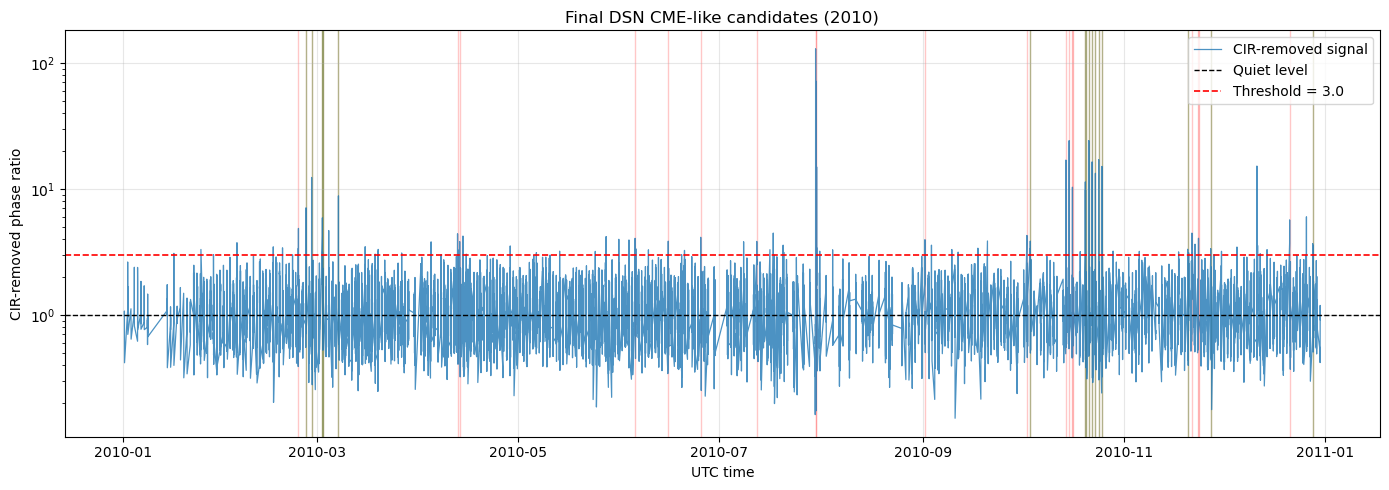

In [16]:
fig, ax = plot_final_cme_candidates(
    windows_flagged,
    final_events,
    year=YEAR,
)

# overlay supported events
for _, e in final_events.iterrows():
    if e["cactus_crosses_p_point"]:
        ax.axvspan(e["start"], e["end"], color="green", alpha=0.3)

plt.show()



Supported duration: 0.6666666666666666
Unsupported duration: 0.5
Supported peak: 9.81783420224592
Unsupported peak: 4.401308994604334
Supported median signal: 6.409756839715314
Unsupported median signal: 3.8597265928448223


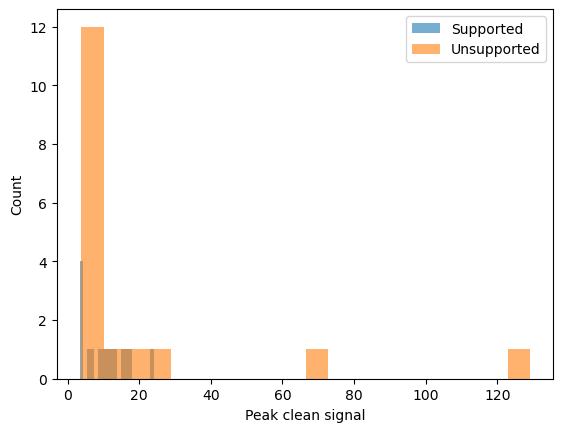

Supported contrast: 1.3443557333461487
Unsupported contrast: 1.180663549023026


In [17]:
supported = final_events[final_events["cactus_crosses_p_point"]]
unsupported = final_events[~final_events["cactus_crosses_p_point"]]

supported = final_events[final_events["cactus_crosses_p_point"] == True]
unsupported = final_events[final_events["cactus_crosses_p_point"] == False]

print("Supported duration:", supported["duration_hr"].median())
print("Unsupported duration:", unsupported["duration_hr"].median())
print("Supported peak:", supported["peak_clean_signal"].median())
print("Unsupported peak:", unsupported["peak_clean_signal"].median())
print("Supported median signal:", supported["median_clean_signal"].median())
print("Unsupported median signal:", unsupported["median_clean_signal"].median())
plt.hist(supported["peak_clean_signal"], bins=20, alpha=0.6, label="Supported")
plt.hist(unsupported["peak_clean_signal"], bins=20, alpha=0.6, label="Unsupported")
plt.legend()
plt.xlabel("Peak clean signal")
plt.ylabel("Count")
plt.show()

final_events["contrast"] = (
    final_events["peak_clean_signal"] /
    final_events["median_clean_signal"]
)

supported = final_events[final_events["cactus_crosses_p_point"] == True].copy()
unsupported = final_events[final_events["cactus_crosses_p_point"] == False].copy()

print("Supported contrast:", supported["contrast"].median())
print("Unsupported contrast:", unsupported["contrast"].median())